In this notebook I will be trying to replicate the dust model explained in Birnstiel et al, 2018, called DSHARP:

https://ui.adsabs.harvard.edu/abs/2018ApJ...869L..45B/abstract

There is really helpful documentation on github: 

https://github.com/birnstiel/dsharp_opac/tree/master/notebooks

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

In [3]:
import dsharp_opac as opacity

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [4]:
from matplotlib.ticker import ScalarFormatter

from scipy.stats import powerlaw

In [5]:
# From Kataoka et 1l, 2015 the grain sizes they are showing are 10 micron, 100 micron, 1 mm and 1 cm
a_max_values_micron = [10, 100, 1000, 10000]

### Complex refractive indicies (m):

Complex refractive indicies (m):
- Water ice: Warren & Brandt 2008
- Astronomical silicates: Draine 2003
- Troilite: Henning & Stognienko 1996
- Refractory organics: Henning & Stognienko 1996

In [6]:
optical_constants_labels = ['Water ice', 'Organics', 'Troilite', 'Astronomical Silicates']

In [7]:
df_wi, df_tr, df_as, df_ro = load_optical_constants()

### Recreate Figure 1

Their x-axis goes from $10^{-5}$ to $10^1$ but is in cm


$10^{-5}$ cm = 0.1 = $10^{-1}$ $\mu$m

$10^1$ cm = 100000 = $10^5$ $\mu$m

So, my wavelength in $mu$m on the x-axis ranges from $10^x$ to $10^x$

In [8]:
# Add lines for the legend
# B_fig1_colors = ['blue', 'gold', 'limegreen', 'red']

B_fig1_colors = ['#63a1cc', '#f9a658', '#6cbd6c', '#e26869']
warren_color = B_fig1_colors[2]
draine_color = B_fig1_colors[3]
henning_color = B_fig1_colors[0]

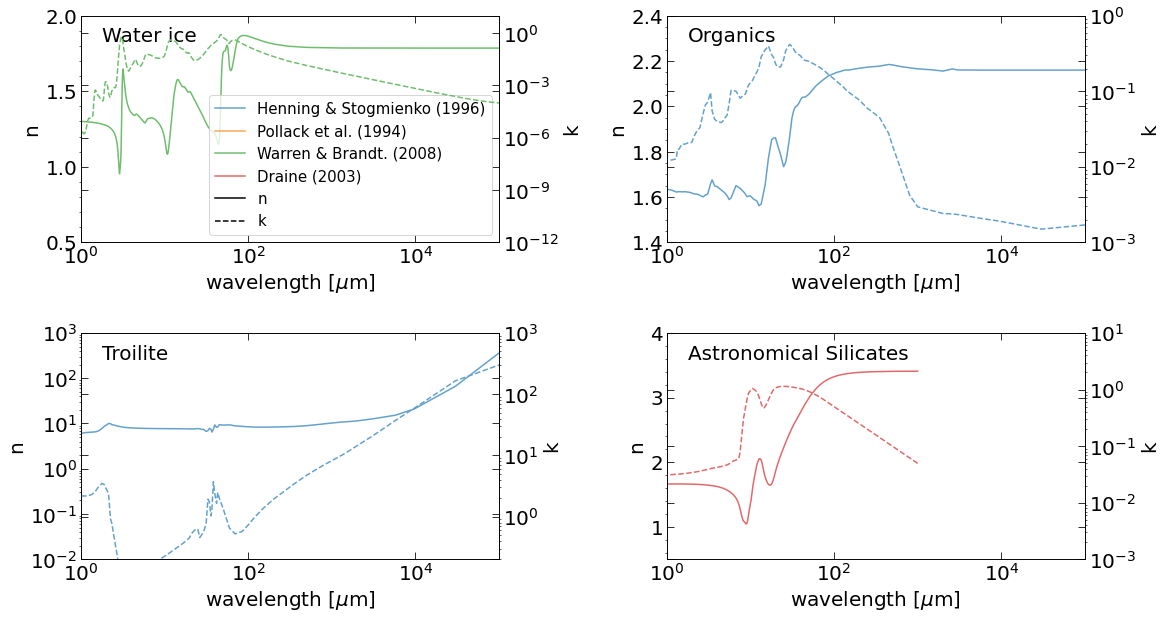

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(18, 10))

# Create secondary y-axes
ax2 = [[ax[i, j].twinx() for j in range(2)] for i in range(2)]

# Add the legend in the top left figure
ax[0, 0].plot(0, 0, color = B_fig1_colors[0], ls = '-', label = 'Henning & Stogmienko (1996)')
ax[0, 0].plot(0, 0, color = B_fig1_colors[1], ls = '-', label = 'Pollack et al. (1994)')
ax[0, 0].plot(0, 0, color = B_fig1_colors[2], ls = '-', label = 'Warren & Brandt. (2008)')
ax[0, 0].plot(0, 0, color = B_fig1_colors[3], ls = '-', label = 'Draine (2003)')
ax[0, 0].plot(0, 0, color = 'black', ls = '-', label = 'n')
ax[0, 0].plot(0, 0, color = 'black', ls = '--', label = 'k')
ax[0, 0].legend(loc = 'lower right', fontsize = legend_text_fs)


# Add data to top left plot (water ice, Warren & Brandt 2008)
ax[0, 0].plot(df_wi['lambda_micron'],  df_wi['n'], ls = '-',  color = warren_color)
ax2[0][0].plot(df_wi['lambda_micron'], df_wi['k'], ls = '--', color = warren_color)

# Add data to top right plot (refractory organics, Henning & Stognienko 1996)
ax[0, 1].plot(df_ro['lambda_micron'],  df_ro['n'], ls = '-',  color = henning_color)
ax2[0][1].plot(df_ro['lambda_micron'], df_ro['k'], ls = '--', color = henning_color)

# Add data to dbottom left plot (troilite, Henning & Stognienko 1996)
ax[1, 0].plot(df_tr['lambda_micron'],  df_tr['n'], ls = '-',  color = henning_color)
ax2[1][0].plot(df_tr['lambda_micron'], df_tr['k'], ls = '--', color = henning_color)

# Add data to bottom right plot (astronomical silicates, Draine 2003)
ax[1, 1].plot(df_as['lambda_micron'],  df_as['n'], ls = '-',  color = draine_color)
ax2[1][1].plot(df_as['lambda_micron'], df_as['k'], ls = '--', color = draine_color)


for i in range(2):
    for j in range(2):
        idx = 2 * i + j
        
        # Add axis labels
        ax[i, j].set_xlabel('wavelength [$\mu$m]', fontsize=axis_label_fs)
        ax[i, j].set_ylabel('n', fontsize=axis_label_fs)
        ax2[i][j].set_ylabel('k', fontsize=axis_label_fs)


        # Adjust ticks on left axis
        ax[i, j].minorticks_on()
        ax[i, j].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
        # Adjust ticks on right axis
        ax2[i][j].minorticks_on()
        ax2[i][j].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
        ax2[i][j].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

        # Remove scientific notation from x-axis
        ax[i, j].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
        ax[i, j].ticklabel_format(style='plain', axis='x')
        
        # Add text
        ax[i, j].text(0.05, 0.95, optical_constants_labels[idx],
              transform=ax[i, j].transAxes,
              fontsize=20,
              va='top', ha='left')
        
        # Make axes log if needed
        ax[i, j].set_xscale('log')
        ax2[i][j].set_yscale('log')
        
        # Set x-axis limits
        ax[i, j].set_xlim(1e0, 1e5)
    
# Make the bottom left plot, left y-axis logscale
ax[1, 0].set_yscale('log')


# Set the limits of th y-axes
ax[0, 0].set_ylim(0.5, 2)
ax2[0][0].set_ylim(1e-12, 1e1)

ax[0, 1].set_ylim(1.4, 2.4)
ax2[0][1].set_ylim(1e-3, 1e0)

ax[1, 0].set_ylim(1e-2, 1e3)
ax2[1][0].set_ylim(2e-1, 1e3)

ax[1, 1].set_ylim(0.5, 4)
ax2[1][1].set_ylim(1e-3, 1e1)
        
# Add spacing between subplots
plt.subplots_adjust(wspace=0.4)
plt.subplots_adjust(hspace=0.4)

## Figure 2

In [15]:
diel, rho_s = opacity.get_dsharp_mix(rule='Bruggeman')
print('Average material density = {:.4f} g/cc'.format(rho_s))

diel = diel.get_normal_object()

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
Average material density = 1.6753 g/cc


(1e-05, 10.0)

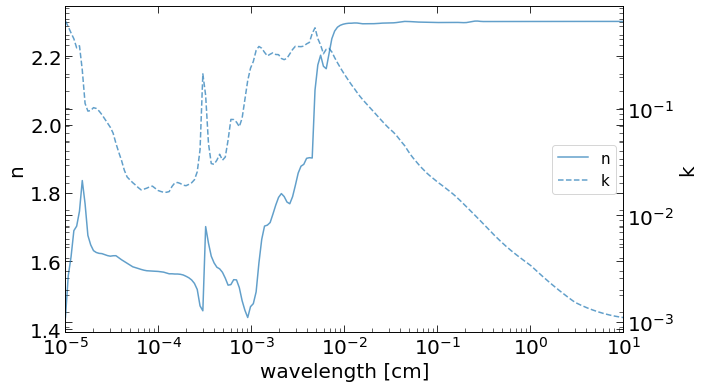

In [32]:
f, ax = plt.subplots(figsize=(10, 6))


lines = [ax.semilogx(diel._l, diel._n, '-', alpha=0.7, label='n')[0]]
ax2 = ax.twinx()
lines += [ax2.loglog(diel._l, diel._k, '--', alpha=0.7, label='k')[0]]

# add legend to last panel
ax.legend(lines, [l.get_label() for l in lines], loc=7, fontsize= legend_text_fs)

# Set axis labels
ax.set_xlabel('wavelength [cm]', fontsize = axis_label_fs)
ax.set_ylabel('n', fontsize = axis_label_fs)
ax2.set_ylabel('k', fontsize = axis_label_fs)

# Adjust ticks on left axis
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)

# Adjust ticks on right axis
ax2.minorticks_on()
ax2.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax2.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)    
ax2.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
# Set axis limits
ax.set_xlim(1e-5, 1e1)

### Other:

In [10]:
N_dsharp = 100

In [11]:
logwave_vals_dsharp = np.linspace(0, 4, N_dsharp)
lambda_micron_array_dsharp = 10**logwave_vals_dsharp

In [12]:
kappa_abs_dsharp = []
kappa_sca_dsharp = []

for a_max in a_max_values_micron:
    kappa_abs = np.linspace(1, a_max/10, N_dsharp)
    kappa_sca = np.linspace(10, a_max/10, N_dsharp)
    
    kappa_abs_dsharp.append(kappa_abs)
    kappa_sca_dsharp.append(kappa_sca)

NameError: name 'a_max_colors' is not defined

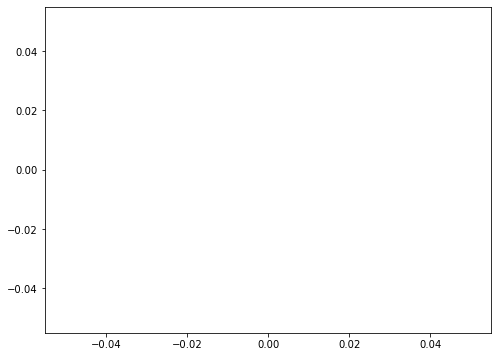

In [13]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(0, 0, color = 'darkgrey', ls = '-', label = '$\kappa_{abs}$')
ax.plot(0, 0, color = 'darkgrey', ls = '--', label = '$\kappa_{sca}$')

# Plot the kappa_abs solid lines
for i in range(4):
    ax.plot(lambda_micron_array_dsharp,
            kappa_abs_dsharp[i],
            color = a_max_colors[i],
            ls = '-',
            label=f'$a_{{max}} = {a_max_values_micron[i]}\\,\\mu m$')
    
# Plot the kappa_abs dashed lines
for i in range(4):
    ax.plot(lambda_micron_array_dsharp,
            kappa_sca_dsharp[i],
            color = a_max_colors[i],
            ls = '--')

# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs, sca}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)


ax.legend(loc = 'lower left', fontsize = legend_text_fs)

# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits
# ax.setxlim()
# ax.set_ylim(10e-8, 10e4)